<a href="https://colab.research.google.com/github/raki-rankawat/thesis-v1/blob/master/Model_VGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model_VGG
Custom VGG-style CNN trained from scratch on VWW.
Used as the **teacher** candidate in knowledge distillation.

In [1]:
# ── Mount Drive & load utils ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import sys, shutil, os
UTILS_SRC = "/content/drive/My Drive/stm32-thesis/utils"
if os.path.exists(UTILS_SRC):
    shutil.copytree(UTILS_SRC, "/content/utils", dirs_exist_ok=True)
    sys.path.insert(0, "/content")
    print("✅ utils loaded from Drive")
else:
    sys.path.insert(0, "/content")
    print("⚠️  Place the utils/ folder at: My Drive/stm32-thesis/utils/")

Mounted at /content/drive
✅ utils loaded from Drive


In [2]:
# ── Imports ─────────────────────────────────────────────────────────
import os, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from utils.dataset import prepare_dataset, get_loaders
from utils.models  import VWW_MobileNetV2, VWW_VGGStyle, VWW_ResNet, count_params, model_size_mb
from utils.train   import setup_device, set_seed, evaluate, train_multi_seed, plot_history

device = setup_device(seed=41)

Device: cuda


In [3]:
prepare_dataset()
train_loader, val_loader = get_loaders(batch_size=64, augmentation="standard")

1/4 Download
⬇️  Downloading VWW archive...
✅ Download complete: /content/vww_work/vw_coco2014_96.tar.gz
2/4 Extract
📦 Extracting VWW archive...
✅ Extraction complete: /content/vww_work/extracted
3/4 Find root
   Root: /content/vww_work/extracted/vw_coco2014_96
4/4 Manifests
✅ Manifests already exist: /content/drive/My Drive/vww_fixed_split_manifests
Train: 7000 | Val: 1500 | Batch: 64


In [4]:
SAVE_DIR = "/content/drive/My Drive/stm32-thesis/checkpoints"

In [5]:
os.makedirs(SAVE_DIR, exist_ok=True)

results, best = train_multi_seed(
    model_fn     = VWW_VGGStyle,
    train_loader = train_loader,
    val_loader   = val_loader,
    device       = device,
    seeds        = [41, 52, 63, 74, 85],
    save_dir     = SAVE_DIR,
    name_prefix  = "vggstyle",
    pretrained   = False,
    epochs          = 50,
    lr              = 1e-3,
    weight_decay    = 1e-4,
    label_smoothing = 0.1,
    patience        = 8,
)


Seed 41
Epoch   1/50 | LR 0.000999 | Train 59.77% | Val 64.80% ✅
Epoch   2/50 | LR 0.000996 | Train 64.31% | Val 60.00%
Epoch   3/50 | LR 0.000991 | Train 66.63% | Val 64.93% ✅
Epoch   4/50 | LR 0.000984 | Train 68.36% | Val 67.47% ✅
Epoch   5/50 | LR 0.000976 | Train 68.09% | Val 70.53% ✅
Epoch   6/50 | LR 0.000965 | Train 70.19% | Val 69.87%
Epoch   7/50 | LR 0.000952 | Train 70.33% | Val 68.13%
Epoch   8/50 | LR 0.000938 | Train 71.33% | Val 73.27% ✅
Epoch   9/50 | LR 0.000922 | Train 71.57% | Val 72.47%
Epoch  10/50 | LR 0.000905 | Train 71.97% | Val 70.00%
Epoch  11/50 | LR 0.000885 | Train 73.24% | Val 70.60%
Epoch  12/50 | LR 0.000864 | Train 73.66% | Val 73.20%
Epoch  13/50 | LR 0.000842 | Train 72.99% | Val 75.20% ✅
Epoch  14/50 | LR 0.000819 | Train 74.19% | Val 75.87% ✅
Epoch  15/50 | LR 0.000794 | Train 75.46% | Val 76.80% ✅
Epoch  16/50 | LR 0.000768 | Train 75.29% | Val 74.00%
Epoch  17/50 | LR 0.000741 | Train 75.74% | Val 73.73%
Epoch  18/50 | LR 0.000713 | Train 76.41

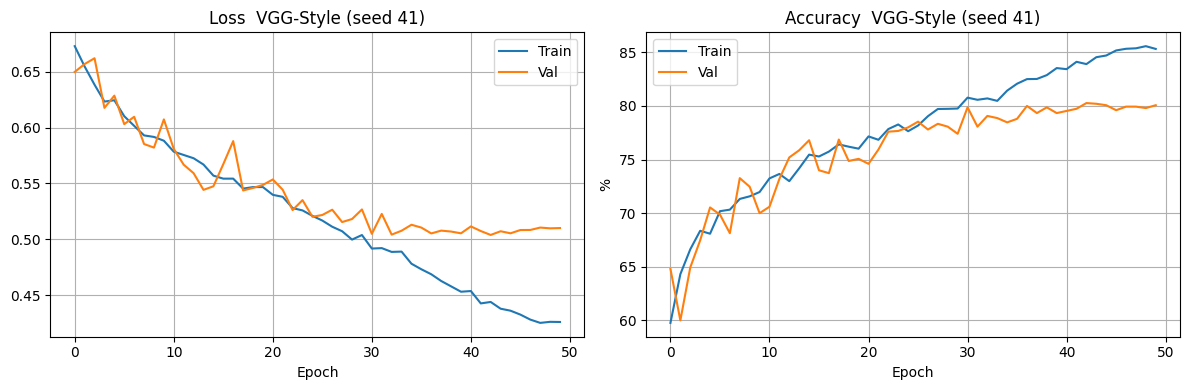

Best: 80.27% @ epoch 43  (12.1 min)

VGG-Style  |  Mean: 79.27% ± 1.36%  |  Best: 80.27% (seed 41)
Best checkpoint: /content/drive/My Drive/stm32-thesis/checkpoints/vggstyle_seed_41.pth


In [6]:
plot_history(best, title=f"VGG-Style (seed {best['seed']})")

accs = [r["best_acc"] for r in results]
print(f"\nVGG-Style  |  Mean: {np.mean(accs)*100:.2f}% ± {np.std(accs)*100:.2f}%  |  Best: {best['best_acc']*100:.2f}% (seed {best['seed']})")
print(f"Best checkpoint: {best['save_path']}")